### 1. Importing Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

### 2. Loading Dataset

In [2]:
# Load dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Preview
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### 3. Basic Info

In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

(2240, 29)

### 4. Data Cleaning

In [5]:
# Check missing values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
# Convert Dt_Customer to datetime
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors='coerce'
)


In [8]:
# Fill missing Income with median
df["Income"].fillna(df["Income"].median(), inplace=True)

### 5. Feature Engineering

In [9]:
# Age calculation
df["Age"] = 2025 - df["Year_Birth"]

In [10]:
# Total spending
df["Total_Spending"] = (
    df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +
    df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
)

In [11]:
# Family size
df["Family_Size"] = df["Kidhome"] + df["Teenhome"] + 1

### 6. Univariate Analysis

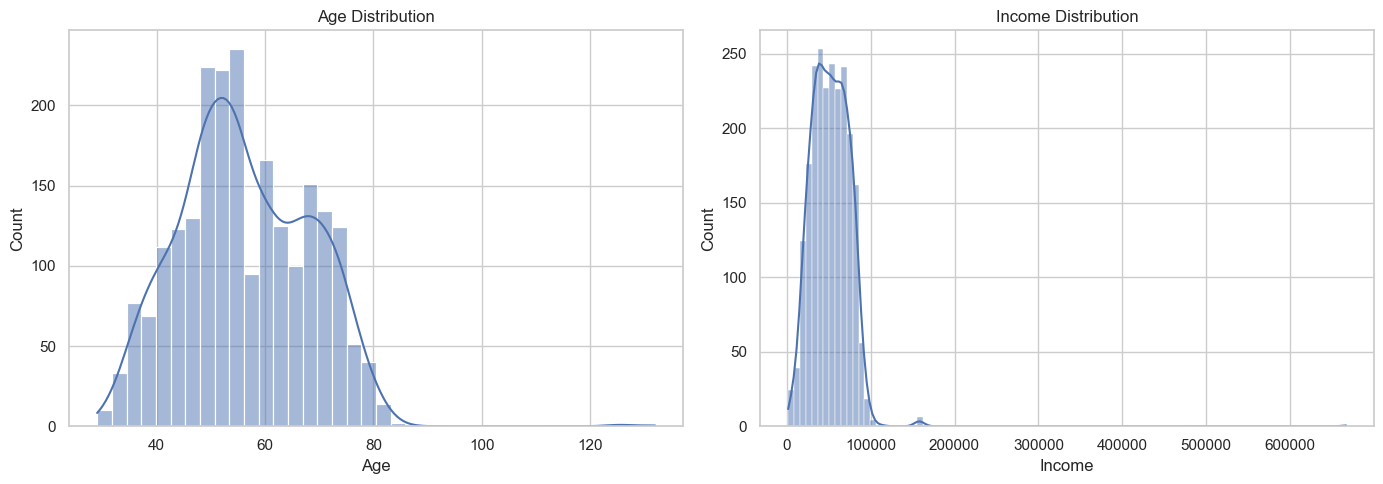

In [15]:
# Create 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age Distribution
sns.histplot(df["Age"], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

# Plot 2: Income Distribution
sns.histplot(df["Income"], kde=True, ax=axes[1])
axes[1].set_title("Income Distribution")

# Adjust layout
plt.tight_layout()

# Show
plt.show()

### 7. Bivariate Analysis

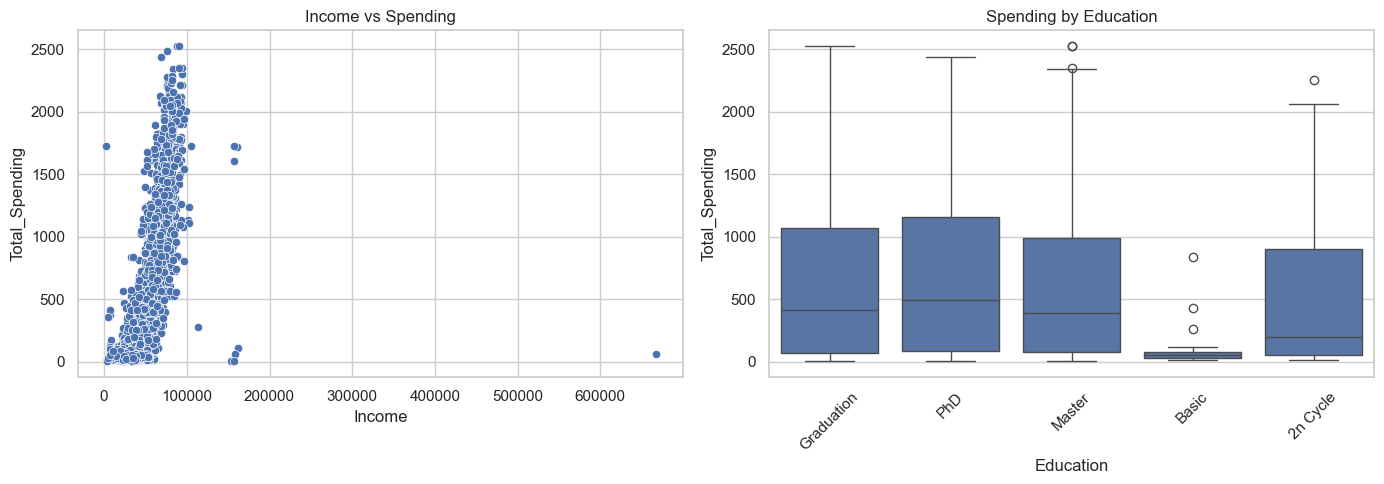

In [14]:
# Create one figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot
sns.scatterplot(x="Income", y="Total_Spending", data=df, ax=axes[0])
axes[0].set_title("Income vs Spending")

# Plot 2: Box plot
sns.boxplot(x="Education", y="Total_Spending", data=df, ax=axes[1])
axes[1].set_title("Spending by Education")
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()

# Show
plt.show()

### 8. Correlation Analysis

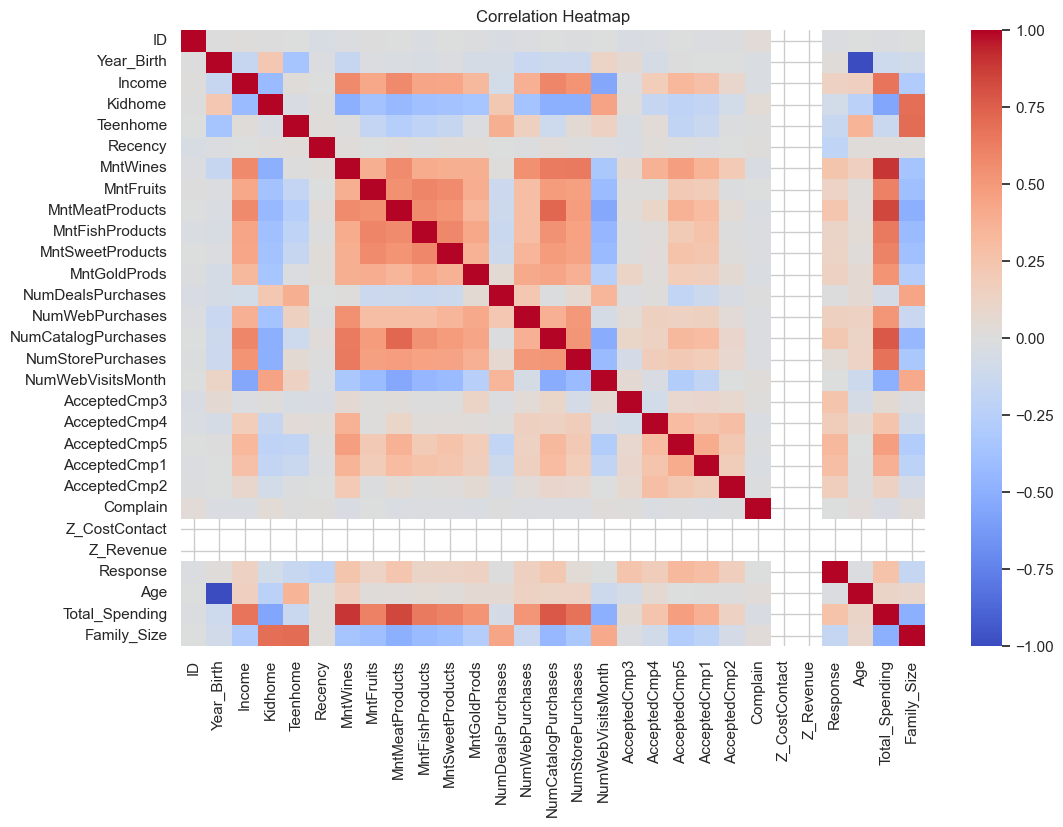

In [16]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 9. Customer Segmentation Insight

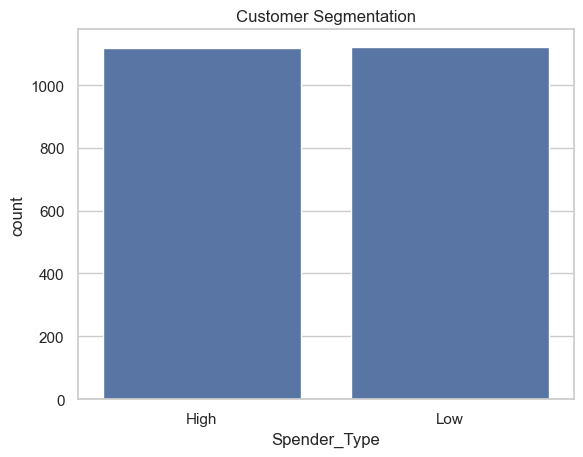

In [17]:
# High vs Low spenders
df["Spender_Type"] = df["Total_Spending"].apply(
    lambda x: "High" if x > df["Total_Spending"].median() else "Low"
)

sns.countplot(x="Spender_Type", data=df)
plt.title("Customer Segmentation")
plt.show()

### 10. Key Insights

- Higher income customers spend more on products
- Wine and meat are top-selling categories
- Middle-aged customers are most active buyers
- Family size impacts spending behavior
- High spenders form a significant segment

### Business Recommendations:

- Target high-income customers with premium offers
- Create family-based discount packages
- Focus marketing on middle-aged demographics

### 11. Save Clean Data

In [18]:
df.to_csv("cleaned_customer_data.csv", index=False)